In [12]:
import os
import re
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- DYNAMIC CONFIGURATION ---
DATA_DIR = '../data'
RF_RATE = 0.07  # Current 10Y G-Sec Yield (Mar 2026)
MARKET_RET = 0.13 # Nifty 50 long-term expected return

# Formatting for clean financial output
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('ggplot')

print(f"✅ Environment Ready. Monitoring data in: {os.path.abspath(DATA_DIR)}")

✅ Environment Ready. Monitoring data in: /home/kunsh/Fintech/Projects/Residual-Finance/data


In [13]:
def get_xml_path(symbol):
    """Finds the latest consolidated XML file for a symbol."""
    try:
        # Look for files starting with symbol and containing 'Consolidated'
        files = [f for f in os.listdir(DATA_DIR) if f.upper().startswith(symbol.upper()) and 'Consolidated' in f]
        if not files:
            return None
        # Sort to get the most recent filename
        files.sort(reverse=True)
        return os.path.join(DATA_DIR, files[0])
    except FileNotFoundError:
        return None

def extract_fundamentals(filepath):
    """Interrogates XBRL tags for Equity and Profit."""
    if not filepath: return 0.0, 0.0
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    def get_tag_value(tag):
        # Handles various XML namespaces and formatting
        pattern = rf'(?i){tag}[^>]*>([\d\s\.,-]+)</'
        match = re.search(pattern, content)
        if match:
            clean_val = match.group(1).replace(',', '').strip()
            return float(clean_val)
        return 0.0

    equity = get_tag_value("EquityAttributableToOwnersOfParent")
    profit = get_tag_value("ProfitLossForPeriod")
    return equity, profit

print("✅ XBRL Parser Logic Loaded.")

✅ XBRL Parser Logic Loaded.


In [14]:
# 1. Auto-discover symbols from downloaded files
all_files = os.listdir(DATA_DIR)
symbols = list(set([f.split('_')[0].upper() for f in all_files if f.endswith('.xml')]))

valuation_results = []

for s in symbols:
    # Fetch Live Market Data
    ticker = yf.Ticker(s + ".NS")
    info = ticker.info
    
    beta = info.get('beta', 1.1)  # Fallback to sector average if Beta is missing
    mcap_cr = info.get('marketCap', 0) / 1e7
    price = info.get('currentPrice', 0)
    
    # Extract Fundamentals
    xml_file = get_xml_path(s)
    equity, profit = extract_fundamentals(xml_file)
    
    if equity == 0:
        print(f"⚠️ Skipping {s}: Missing Fundamental Tags in XML.")
        continue

    # --- VALUATION MATH ---
    # Cost of Equity (CAPM)
    ke = RF_RATE + beta * (MARKET_RET - RF_RATE)
    
    eq_cr = equity / 1e7
    pr_cr = profit / 1e7
    
    # Residual Income = Actual Profit - (Equity * Cost of Capital)
    ri = pr_cr - (eq_cr * ke)
    
    # Intrinsic Value = Equity + (Residual Income / Cost of Capital)
    iv_cr = eq_cr + (ri / ke)
    mos = (iv_cr / mcap_cr) - 1 if mcap_cr > 0 else 0

    valuation_results.append({
        'Symbol': s,
        'Price': price,
        'Beta': beta,
        'Efficiency_%': (pr_cr / eq_cr) * 100,
        'FairValue_Cr': iv_cr,
        'MarketCap_Cr': mcap_cr,
        'Margin_of_Safety': mos
    })

df = pd.DataFrame(valuation_results)
df['Verdict'] = np.where(df['Margin_of_Safety'] > 0.15, 'STRONG BUY', 
                np.where(df['Margin_of_Safety'] > 0, 'BUY', 'OVERVALUED'))

print(f"📊 Processed {len(df)} Stocks.")
display(df.sort_values('Margin_of_Safety', ascending=False))

📊 Processed 2 Stocks.


,Symbol,Price,Beta,Efficiency_%,FairValue_Cr,MarketCap_Cr,Margin_of_Safety,Verdict
1,TCS,"2,389.80",0.20,51.50,"595,521.11","864,650.53",-0.31,OVERVALUED
0,INFY,"1,269.70",0.18,27.92,"330,083.91","513,797.73",-0.36,OVERVALUED


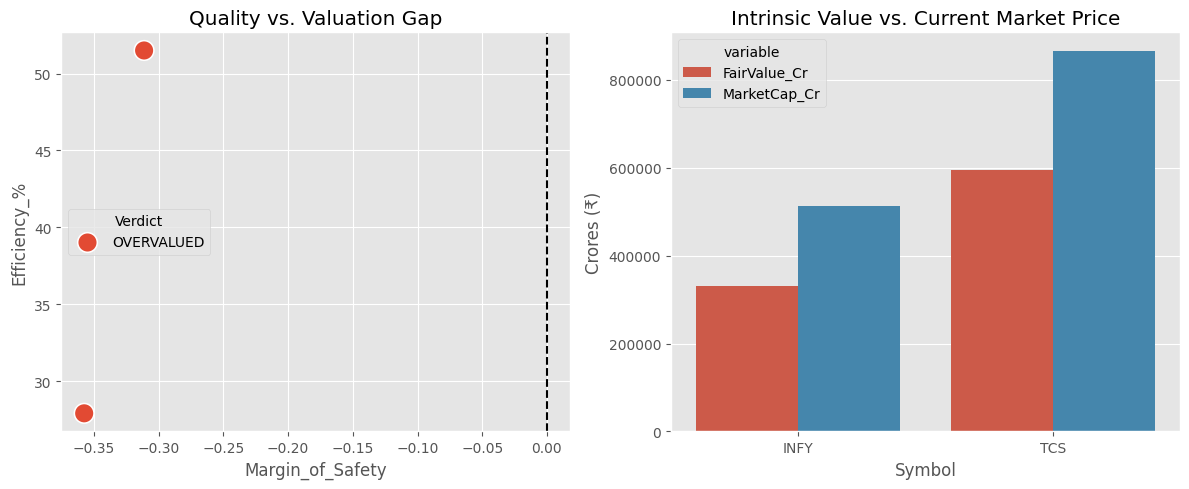

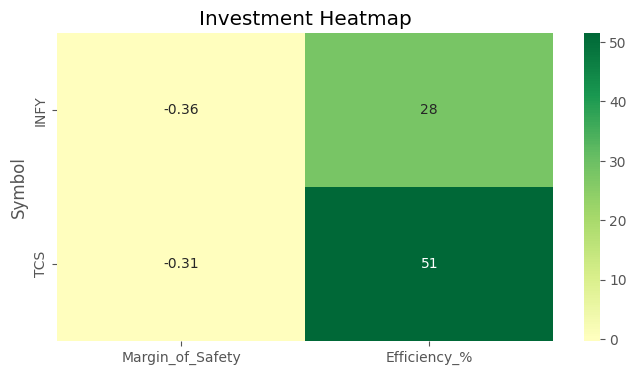

In [15]:
plt.figure(figsize=(12, 5))

# Plot 1: Margin of Safety vs Efficiency
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Margin_of_Safety', y='Efficiency_%', hue='Verdict', s=200)
plt.axvline(0, color='black', linestyle='--')
plt.title("Quality vs. Valuation Gap")

# Plot 2: Fair Value vs Market Cap
plt.subplot(1, 2, 2)
df_melt = df.melt(id_vars='Symbol', value_vars=['FairValue_Cr', 'MarketCap_Cr'])
sns.barplot(data=df_melt, x='Symbol', y='value', hue='variable')
plt.title("Intrinsic Value vs. Current Market Price")
plt.ylabel("Crores (₹)")

plt.tight_layout()
plt.show()

# Final Heatmap for quick scanning
plt.figure(figsize=(8, 4))
sns.heatmap(df.set_index('Symbol')[['Margin_of_Safety', 'Efficiency_%']], annot=True, cmap='RdYlGn', center=0)
plt.title("Investment Heatmap")
plt.show()

🚀 BALANCED STRATEGY (Quality + Value)


,Symbol,Efficiency_%,Margin_of_Safety,Weight_%,Units_to_Buy
0,INFY,27.92,-0.36,41.13,323.00
1,TCS,51.50,-0.31,58.87,246.00


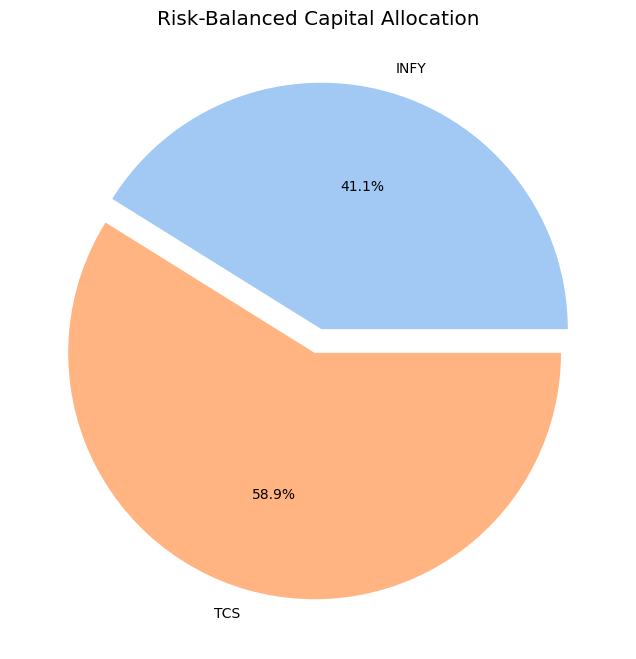

In [17]:
# --- IMPROVED RISK-BALANCED ALLOCATION ---
TOTAL_BUDGET_INR = 1000000 

def calculate_balanced_score(row):
    # We use a base score of 1.0 so no company starts at zero
    # We then add a bonus for efficiency and a penalty/bonus for valuation
    base_score = 1.0 
    quality_bonus = (row['Efficiency_%'] / 100) * 2.0  # Reward efficiency heavily
    valuation_adjustment = row['Margin_of_Safety']     # Add/Subtract based on price
    
    return max(0.1, base_score + quality_bonus + valuation_adjustment)

# 1. Calculate Scores
df['Balanced_Score'] = df.apply(calculate_balanced_score, axis=1)

# 2. Normalize
df['Weight_%'] = (df['Balanced_Score'] / df['Balanced_Score'].sum()) * 100

# 3. Units Calculation
df['Allocated_INR'] = (df['Weight_%'] / 100) * TOTAL_BUDGET_INR
df['Units_to_Buy'] = np.floor(df['Allocated_INR'] / df['Price'])

# --- REVISED REPORT ---
print("🚀 BALANCED STRATEGY (Quality + Value)")
display(df[['Symbol', 'Efficiency_%', 'Margin_of_Safety', 'Weight_%', 'Units_to_Buy']])

# --- REVISED PIE CHART ---
plt.figure(figsize=(8, 8))
plt.pie(df['Weight_%'], labels=df['Symbol'], autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), explode=[0.05]*len(df))
plt.title("Risk-Balanced Capital Allocation")
plt.show()